## Import thư viện và khởi tạo OCR Engine

In [ ]:
import sys
sys.path.insert(0, '..')

import os
import json
import glob
import matplotlib.pyplot as plt
from PIL import Image

from src.ocr.ocr_processor import PaddleOCRProcessor

# Khởi tạo OCR processor
ocr_processor = PaddleOCRProcessor(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

c:\Users\Thach\miniconda3\envs\project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


Đang khởi tạo PaddleOCR engine...


c:\Users\Thach\miniconda3\envs\project\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_rec`.


-> PaddleOCR đã sẵn sàng!


## Cấu hình đường dẫn

In [ ]:
from src.Preprocessing.constant import *
from src.layout import *

Input folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_Images
Output folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_OCR


## Chọn 1 ảnh mẫu

['../dataset/DocVQA_Images\\train\\10260.png']
Chạy OCR với Layout Analysis...

KẾT QUẢ LAYOUT ANALYSIS
Số lines: 34
Số blocks: 23
Số regions: 5

Regions phát hiện:
--------------------------------------------------------------------------------

1. Type: FORM | Score: 0.593
   - Colon ratio: 0.33
   - Left alignment: 1.00
   - Right alignment: 0.89

2. Type: FORM | Score: 0.556
   - Colon ratio: 0.25
   - Left alignment: 1.00
   - Right alignment: 0.90

3. Type: FORM | Score: 0.275
   - Colon ratio: 0.25
   - Left alignment: 1.00
   - Right alignment: 0.94

4. Type: TEXT | Score: 0.683
   - Avg line length: 39.0
   - Spacing uniformity: 0.98

5. Type: TEXT | Score: 0.725
   - Avg line length: 45.0
   - Spacing uniformity: 1.00


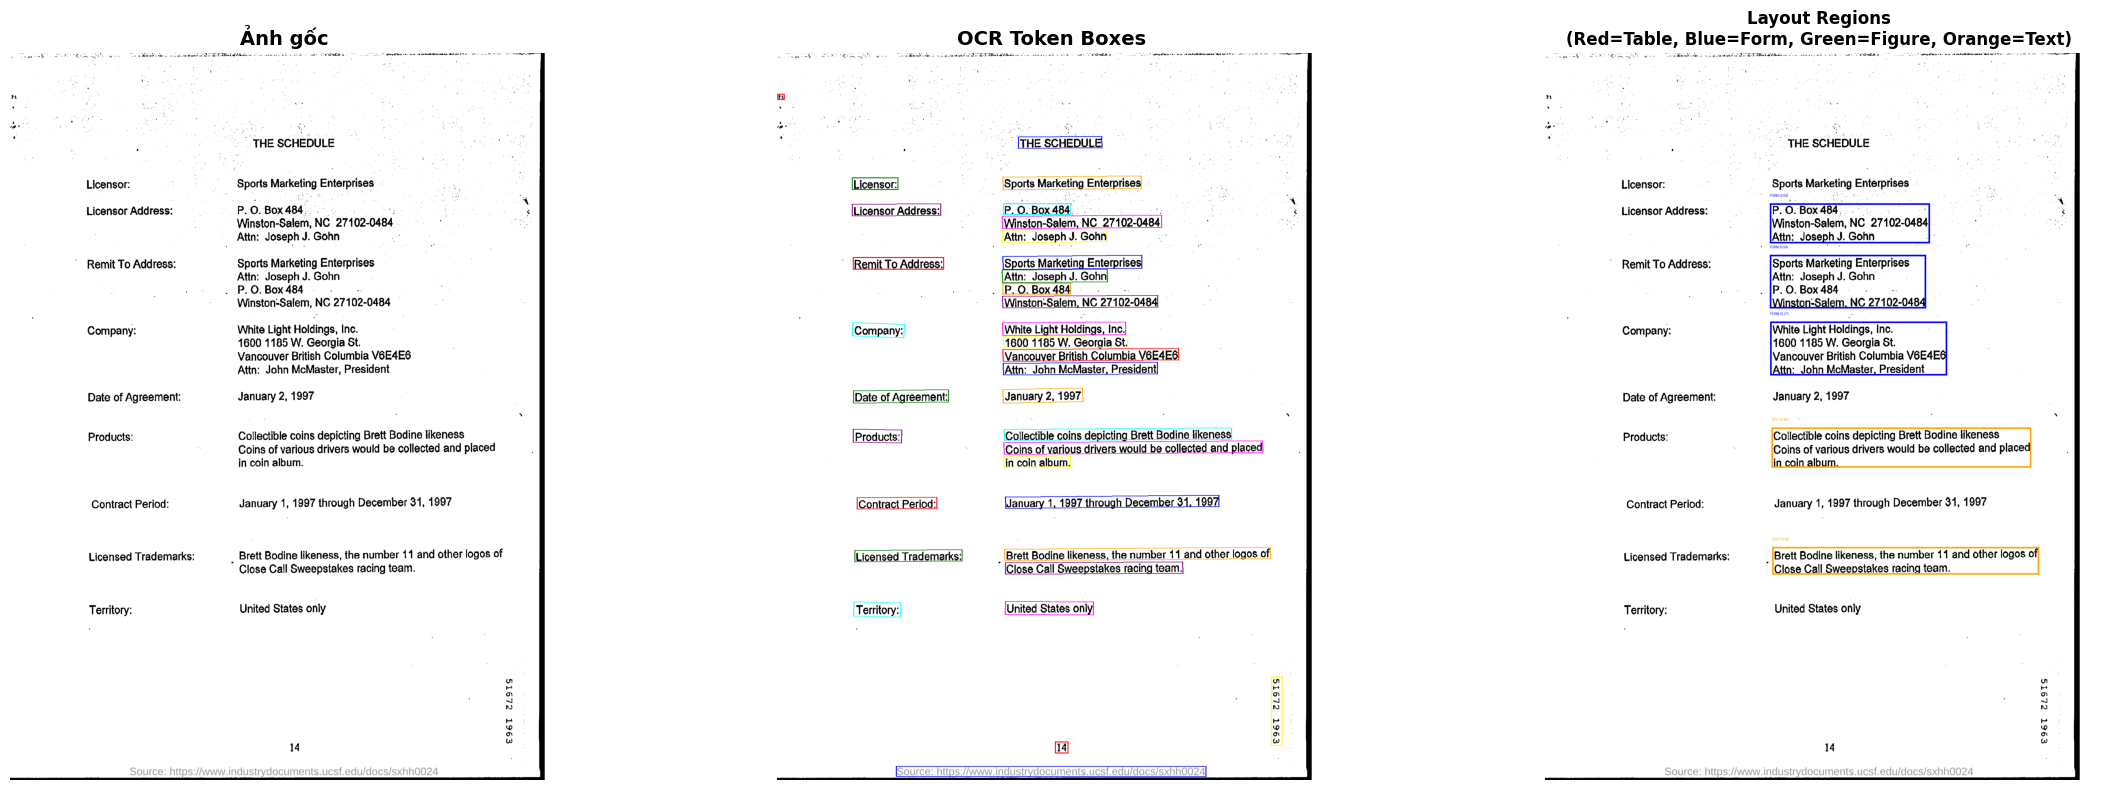


LEGEND - Region Colors:
  🔴 RED    = Table (bảng)
  🔵 BLUE   = Form (key:value)
  🟢 GREEN  = Figure (chart/plot)
  🟠 ORANGE = Text (đoạn văn)
  🟣 PURPLE = Layout (multi-column/heading)

TEXT CONTENT THEO TỪNG REGION

────────────────────────────────────────────────────────────────────────────────
📋 FORM REGIONS (3 phát hiện)
────────────────────────────────────────────────────────────────────────────────

[FORM #1] Score: 0.593
────────────────────────────────────────
 1. P. O. Box 484
 2. Winston-Salem, NC 27102-0484
 3. Attn: Joseph J. Gohn

[FORM #2] Score: 0.556
────────────────────────────────────────
 1. Sports Marketing Enterprises
 2. Attn: Joseph J. Gohn
 3. P. O. Box 484
 4. Winston-Salem, NC 27102-0484

[FORM #3] Score: 0.275
────────────────────────────────────────
 1. White Light Holdings, Inc.
 2. 1600 1185 W. Georgia St.
 3. Vancouver British Columbia V6E4E6
 4. Attn: John McMaster, President

─────────────────────────────────────────────────────────────────────────────

In [12]:
# Tìm 1 ảnh mẫu
import random

sample_image = None
idx = random.randint(0, 1000)
if sample_image is None:
    for subset in SUBSETS:
        subset_folder = os.path.join(IMAGES_FOLDER, subset)
        if os.path.exists(subset_folder):
            images = glob.glob(os.path.join(subset_folder, "*.png"))[idx:idx+1]
            print(images)
            if images:
                sample_image = images[0]
                break
else:
    images = os.path.join(IMAGES_FOLDER, 'train', f'{sample_image}.png')
    
group(sample_image, ocr_processor)

## So sánh ảnh trước và sau preprocess

In [4]:
# preprocess(sample_image, ocr_processor)

---
## Document Layout Analysis

Phân tích cấu trúc document sau khi OCR:
- **Stage I**: Group token → line → block
- **Stage II**: Detect regions (table, form, figure, text, layout)

## Visualize Stage I Groups

Hiển thị các bước grouping ở Stage I:
- **Token**: Các bounding box từ OCR
- **Line**: Gộp tokens thành lines
- **Block**: Gộp lines thành blocks

In [5]:
visualize_stage1_groups(sample_image, ocr_processor)

Chạy OCR với Layout Analysis...
Không có kết quả layout


In [6]:
# group(sample_image, ocr_processor)

## Xử lý OCR hàng loạt cho toàn bộ Dataset

In [7]:
# # Xử lý OCR cho 500 ảnh đầu tiên của mỗi subset với PREPROCESSING
# all_stats = ocr_processor.process_docvqa_images(
#     images_folder=IMAGES_FOLDER,
#     output_folder=OUTPUT_FOLDER,
#     subsets=SUBSETS,
#     max_images_per_subset=500,  # Giới hạn 500 ảnh mỗi subset
#     use_preprocessing=True,      # BẬT preprocessing
#     max_size=2500                # Resize max 2500px
# )

## Xem kết quả đã xử lý

In [8]:
# # Đếm số file JSON đã tạo
# print("="*60)
# print("THỐNG KÊ KẾT QUẢ OCR")
# print("="*60)

# for subset in SUBSETS:
#     subset_output = os.path.join(OUTPUT_FOLDER, subset)
#     if os.path.exists(subset_output):
#         json_files = glob.glob(os.path.join(subset_output, "*.json"))
#         print(f"  {subset:15}: {len(json_files):,} files")
#     else:
#         print(f"  {subset:15}: 0 files (chưa xử lý)")

# # Đếm tổng
# total_json = len(glob.glob(os.path.join(OUTPUT_FOLDER, "**/*.json"), recursive=True))
# print("="*60)
# print(f"  {'TỔNG':15}: {total_json:,} files")